# Import Statements

In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [10]:
import pickle
import numpy as np
import pandas as pd
import scipy
import sklearn
import shap
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm as notebook_tqdm
import skopt
import copy

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from scipy import stats
from math import sqrt
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [12]:
from platform import python_version

print(python_version())


3.10.12


In [13]:
print(np.__version__)

1.26.3


# Define all functions

In [14]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

# set parameter space for LASSO

lasso_space = {
    'alpha': Real(1e-5, 1.0, 'log-uniform')  # L1 penalty term
}

In [15]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [16]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor(n_jobs=1)
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-11,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 


def bayesian_lasso_search(X, y, lasso_space):
    lasso = Lasso(max_iter=100000)
    lasso_bayes_search = BayesSearchCV(
        estimator=lasso,
        search_spaces=lasso_space,
        scoring=None,
        cv=5,
        n_iter=10,  # number of iterations to try
        random_state=42,
        verbose=1,
        n_jobs=-1
)
    lasso_bayes_search.fit(X, y)
    
    print("Best Lasso hyperparameters:", lasso_bayes_search.best_params_)
    
    best_params = lasso_bayes_search.best_params_
    best_lasso = Lasso(**best_params)

    return best_lasso
    
#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [17]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, X, y, k):
    """
    Evaluates model using k-fold CV and returns the final model trained on full dataset.
    
    Parameters:
    m: model (e.g., XGBoost or RandomForest) with best hyperparameters
    X: feature matrix
    y: labels
    k: number of folds
    """
    cv = KFold(n_splits=k, shuffle=True)
    rmse_results = []
    percent_rmse_results = []
    r2_results = []
 
    low = 100
    best_fold_model = None
    
    for fold, (train, test) in enumerate(cv.split(X, y), start=1):
        print(f"\n=== Fold {fold} ===")
        
        m.fit(X[train], y[train].ravel())
        preds = m.predict(X[test])
        
        ss = sqrt(mean_squared_error(y[test], preds))  
        rr = r2_score(y[test], preds)                  
        mm = np.mean(y[test])
        error_mean = (ss / mm) * 100
        
        rmse_results.append(ss)
        percent_rmse_results.append(error_mean)
        r2_results.append(rr)
        
        print(f"R²: {rr:.4f}, RMSE: {ss:.4f}, %RMSE: {error_mean:.2f}")
        
        if error_mean < low:
            low = error_mean
            best_fold_model = copy.deepcopy(m)
    
    print("\nCV Summary:")
    print(f"Mean %RMSE: {np.mean(percent_rmse_results):.2f} ± {np.std(percent_rmse_results):.2f}")
    
    # Plot %RMSE per fold
    plt.figure(figsize=(8,5), dpi=300)
    cb_palette = ["#E69F00", "#56B4E9", "#009E73"]
    plt.plot(range(1, k+1), percent_rmse_results, marker="o", label="%RMSE", color=cb_palette[0])
    plt.plot(range(1, k+1), rmse_results, marker="s", label="RMSE", color=cb_palette[1])
    plt.plot(range(1, k+1), r2_results, marker="^", label="R²", color=cb_palette[2])
    plt.xlabel("Fold Number")
    plt.ylabel("Metric Value")
    plt.title("Cross-Validation Metrics per Fold")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Retrain the best model on full dataset
    final_model = copy.deepcopy(best_fold_model)
    final_model.fit(X, y.ravel())
    
    metrics = {
        "RMSE": rmse_results,
        "%RMSE": percent_rmse_results,
        "R2": r2_results
    }
    
    return final_model, metrics

#TO RUN - best_model_xgb, results = eval_k_fold(model, X, y, 10)

In [18]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20, savepath=None):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    fig = plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    # Save at 600 dpi if path given
    if savepath is not None:
        fig.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [19]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6), dpi=300)
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [20]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# Load dataset

In [102]:
geno = pd.read_pickle("pfam_pav_newIDs_eval5_afterFS.pkl")

In [103]:
geno.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,PF00069_UWASoyPan05055,PF07651_UWASoyPan05083,PF01541_UWASoyPan05113,PF07014_UWASoyPan05162,PF03140_UWASoyPan05171,PF06026_UWASoyPan05196,PF00232_UWASoyPan05231,PF07651_UWASoyPan05301,PF01657_UWASoyPan05311,PF00931_UWASoyPan05312
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,1,1,0,0
AB-02,0,0,1,1,1,1,1,1,1,1,...,0,1,0,1,0,0,1,1,0,1
BR-01,1,1,1,1,1,1,1,1,1,1,...,0,1,0,1,0,0,1,1,0,1
BR-02,1,1,1,1,1,1,1,1,1,1,...,0,1,0,1,0,0,1,1,0,1
BR-03,1,1,1,1,1,0,0,1,1,1,...,0,1,0,1,0,0,1,1,0,0


In [104]:
geno.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1110 entries, AB-01 to USB-046
Columns: 1196 entries, PF00931_01G030900 to PF00931_UWASoyPan05312
dtypes: int64(1196)
memory usage: 10.1+ MB


In [105]:
pheno =  pd.read_pickle("phenotype_yield_data.pkl")

In [106]:
pheno.head()

,Data-storage-ID,new_line,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
0,USB-756,USB-756_SOYBEAN.EVALUATION.MS989,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0.08
1,USB-014,USB-014_SOYBEAN.EVALUATION.MN0102,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.09
2,USB-035,USB-035_SOYBEAN.EVALUATION.MS2000_02,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0.14
3,USB-499,USB-499_SOYBEAN.EVALUATION.MS923,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0.15
4,USB-393,USB-393_SOYBEAN.EVALUATION.MN0102,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.15


In [107]:
pheno.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Data-storage-ID                  893 non-null    object 
 1   new_line                         893 non-null    object 
 2   SOYBEAN.EVALUATION.1IL64         893 non-null    int64  
 3   SOYBEAN.EVALUATION.1IL66         893 non-null    int64  
 4   SOYBEAN.EVALUATION.1MN63         893 non-null    int64  
 5   SOYBEAN.EVALUATION.2IL81.1       893 non-null    int64  
 6   SOYBEAN.EVALUATION.2IL81.2       893 non-null    int64  
 7   SOYBEAN.EVALUATION.2KY81         893 non-null    int64  
 8   SOYBEAN.EVALUATION.2MN81         893 non-null    int64  
 9   SOYBEAN.EVALUATION.3IL83.1       893 non-null    int64  
 10  SOYBEAN.EVALUATION.3IL83.2       893 non-null    int64  
 11  SOYBEAN.EVALUATION.3IL84         893 non-null    int64  
 12  SOYBEAN.EVALUATION.3MN

In [108]:
Final_data = pd.merge(geno, pheno, on='Data-storage-ID', how='right', indicator=False)

In [109]:
Final_data.head()

,Data-storage-ID,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
0,USB-756,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,1,0.08
1,USB-014,0,0,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0.09
2,USB-035,0,0,1,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0.14
3,USB-499,1,1,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0.15
4,USB-393,1,1,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0.15


In [110]:
Final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Columns: 1230 entries, Data-storage-ID to observation_value
dtypes: float64(1), int64(1227), object(2)
memory usage: 8.4+ MB


In [111]:
nan_values = Final_data[Final_data.isna().any(axis=1)] 

In [112]:
nan_values.head()

,Data-storage-ID,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value


In [78]:
Final_data.to_pickle("Full_set_pfam_yield_data.pkl") 

In [79]:
Final_data = pd.read_pickle("Full_set_pfam_yield_data.pkl")
Final_data.head()

,Data-storage-ID,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
0,USB-756,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,1,0.08
1,USB-014,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0.09
2,USB-035,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0.14
3,USB-499,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0.15
4,USB-393,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0.15


In [113]:
#Final_data = Final_data.set_index("Data-storage-ID")
Final_data = Final_data.set_index("new_line")

In [114]:
Final_data.head()

,Data-storage-ID,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
USB-756_SOYBEAN.EVALUATION.MS989,USB-756,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,1,0.08
USB-014_SOYBEAN.EVALUATION.MN0102,USB-014,0,0,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0.09
USB-035_SOYBEAN.EVALUATION.MS2000_02,USB-035,0,0,1,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0.14
USB-499_SOYBEAN.EVALUATION.MS923,USB-499,1,1,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0.15
USB-393_SOYBEAN.EVALUATION.MN0102,USB-393,1,1,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0.15


In [82]:
Final_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 893 entries, USB-756_SOYBEAN.EVALUATION.MS989 to HNY-58_SOYBEAN.EVALUATION.MS2011_12
Columns: 53754 entries, Data-storage-ID to observation_value
dtypes: float64(1), int64(53752), object(1)
memory usage: 366.2+ MB


In [130]:
#Split dataset into training,test and holdout

In [83]:
snps = Final_data.iloc[:, 1:53753]
snps.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
new_line,,,,,,,,,,,,,,,,,,,,,
USB-756_SOYBEAN.EVALUATION.MS989,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1
USB-014_SOYBEAN.EVALUATION.MN0102,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-035_SOYBEAN.EVALUATION.MS2000_02,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
USB-499_SOYBEAN.EVALUATION.MS923,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,0,0,0
USB-393_SOYBEAN.EVALUATION.MN0102,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [85]:
seed_oil = Final_data.iloc[:, 53753:]
seed_oil.head()

,observation_value
new_line,
USB-756_SOYBEAN.EVALUATION.MS989,0.08
USB-014_SOYBEAN.EVALUATION.MN0102,0.09
USB-035_SOYBEAN.EVALUATION.MS2000_02,0.14
USB-499_SOYBEAN.EVALUATION.MS923,0.15
USB-393_SOYBEAN.EVALUATION.MN0102,0.15


In [86]:
X_full, X_holdout, y_full, y_holdout = train_test_split(snps, seed_oil, test_size=0.1, random_state=42, shuffle=True)

In [87]:
X_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, HNSM-03_SOYBEAN.EVALUATION.2KY81 to USB-752_SOYBEAN.EVALUATION.MS989
Columns: 53752 entries, PF02776_01G000400 to SOYBEAN.EVALUATION.MS989
dtypes: int64(53752)
memory usage: 329.3+ MB


In [88]:
X_full.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-127_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
USB-475_SOYBEAN.EVALUATION.1IL66,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0


In [89]:
y_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, HNSM-03_SOYBEAN.EVALUATION.2KY81 to USB-752_SOYBEAN.EVALUATION.MS989
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   observation_value  803 non-null    float64
dtypes: float64(1)
memory usage: 12.5+ KB


In [90]:
y_full.head()

,observation_value
new_line,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1.50
USB-127_SOYBEAN.EVALUATION.MS1999_01,2.47
USB-475_SOYBEAN.EVALUATION.1IL66,2.65
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,2.12
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1.06


In [30]:
X_full.to_pickle("x_full_pav.pkl")
X_holdout.to_pickle("x_holdout_pav.pkl")
y_full.to_pickle("y_full_pav.pkl")
y_holdout.to_pickle("y_holdout_pav.pkl")

In [91]:
#You have to kep new_line as index because the index needs to be unique while doing an outer merge, else the duplicated ones gets duplicated again
#training_data = pd.merge(X_full, y_full, on='Data-storage-ID', how='right', indicator=True)
training_data = pd.merge(X_full, y_full, on='new_line', how='right', indicator=False)

In [92]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, HNSM-03_SOYBEAN.EVALUATION.2KY81 to USB-752_SOYBEAN.EVALUATION.MS989
Columns: 53753 entries, PF02776_01G000400 to observation_value
dtypes: float64(1), int64(53752)
memory usage: 329.3+ MB


In [93]:
training_data.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.50
USB-127_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,2.47
USB-475_SOYBEAN.EVALUATION.1IL66,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.65
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.12
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,1.06


In [94]:
nan_values = Final_data[Final_data.isna().any(axis=1)] 

In [95]:
nan_values.head()

,Data-storage-ID,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,


In [96]:
X_holdout.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
new_line,,,,,,,,,,,,,,,,,,,,,
USB-212_SOYBEAN.EVALUATION.4IL87,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-540_SOYBEAN.EVALUATION.3IL84,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-694_SOYBEAN.EVALUATION.IL945,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-735_SOYBEAN.EVALUATION.IL0102,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-264_SOYBEAN.EVALUATION.MS945,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,1,0,0


In [97]:
holdout_data = pd.merge(X_holdout, y_holdout, on='new_line', how='outer', indicator=False)

In [98]:
holdout_data.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
ESS_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,3.60
HN012_SOYBEAN.EVALUATION.IL945,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.86
HN018_SOYBEAN.EVALUATION.3IL83.2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.87
HN037_SOYBEAN.EVALUATION.1IL64,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.88
HN060_SOYBEAN.EVALUATION.4IL87,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.02


In [99]:
holdout_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, ESS_SOYBEAN.EVALUATION.MS1999_01 to USB-807_SOYBEAN.EVALUATION.MS2011_12
Columns: 53753 entries, PF02776_01G000400 to observation_value
dtypes: float64(1), int64(53752)
memory usage: 36.9+ MB


In [100]:
training_data.to_pickle("pfam_pav_newIDs_eval5_yield_training_data.pkl")

In [101]:
holdout_data.to_pickle("pfam_pav_newIDs_eval5_yield_holdout_data_pav.pkl")

# LASSO for feature selection

In [115]:
#Load file
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, HNSM-03_SOYBEAN.EVALUATION.2KY81 to USB-752_SOYBEAN.EVALUATION.MS989
Columns: 53753 entries, PF02776_01G000400 to observation_value
dtypes: float64(1), int64(53752)
memory usage: 329.3+ MB


In [116]:
training_data.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.50
USB-127_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,2.47
USB-475_SOYBEAN.EVALUATION.1IL66,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.65
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.12
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,1.06


In [117]:
#Extract only SNPs for feature selection

In [120]:
feature= training_data.iloc[:, 0:53721]
feature.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,PF00112_UWASoyPan05296,PF08246_UWASoyPan05296,PF03900_UWASoyPan05297,PF00957_UWASoyPan05299,PF13774_UWASoyPan05299,PF07651_UWASoyPan05301,PF01253_UWASoyPan05303,PF01657_UWASoyPan05311,PF00931_UWASoyPan05312,PF02427_UWASoyPan05315
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,1,0
USB-127_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
USB-475_SOYBEAN.EVALUATION.1IL66,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0


In [122]:
target = training_data["observation_value"]
target.head()

new_line
HNSM-03_SOYBEAN.EVALUATION.2KY81           1.50
USB-127_SOYBEAN.EVALUATION.MS1999_01       2.47
USB-475_SOYBEAN.EVALUATION.1IL66           2.65
SRR1533290_SOYBEAN.EVALUATION.3IL83.2      2.12
SRR1533220_SOYBEAN.EVALUATION.MS1999_01    1.06
Name: observation_value, dtype: float64

In [125]:
cov = training_data.iloc[:,-32:]
cov.head()

,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,SOYBEAN.EVALUATION.3IL83.2,SOYBEAN.EVALUATION.3IL84,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.50
USB-127_SOYBEAN.EVALUATION.MS1999_01,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,2.47
USB-475_SOYBEAN.EVALUATION.1IL66,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.65
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,2.12
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1.06


In [126]:
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

In [135]:
X_train_subset = X_train.iloc[:, :1000]
X_train_subset.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,Gm01_1784630,Gm01_1786373,Gm01_1788214,Gm01_1790690,Gm01_1790867,Gm01_1792041,Gm01_1792969,Gm01_1793822,Gm01_1794245,Gm01_1796361
new_line,,,,,,,,,,,,,,,,,,,,,
USB-201_SOYBEAN.CHEMICAL.NB.2009,0,1,0,1,0,0,0,0,0,1,...,2,2,0,0,0,0,0,2,0,0
USB-279_SOYBEAN.EVALUATION.MS2000_02,0,0,1,0,0,1,0,0,0,0,...,0,2,2,0,0,0,0,0,0,0
USB-117_SOYBEAN.EVALUATION.1IL66,0,0,0,1,0,0,0,0,0,0,...,2,2,0,0,0,0,0,2,0,0
HN053_WILD.SOYBEAN.EVAL.1IL85,0,0,0,0,1,0,0,0,0,0,...,0,2,2,0,0,0,0,0,0,0
USB-603_SOYBEAN.GENERAL,1,0,0,0,0,1,1,0,0,0,...,0,2,2,0,0,0,0,1,0,0


In [127]:
best_lasso = bayesian_lasso_search(X_train, y_train, lasso_space)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Lasso hyperparameters: OrderedDict([('alpha', 0.012172976749510152)])


In [128]:
# Create a Lasso Regression model with the best parameters from bayes CV

alpha = 0.0122  # Regularization strength (adjust from best_params)
best_lasso_model = Lasso(alpha=alpha)

# Fit the model to the full training data
best_lasso_model.fit(feature, target)

Lasso(alpha=0.0122)

In [129]:
names=feature.columns
print("Column Names: {}".format(names.values))

Column Names: ['PF02776_01G000400' 'PF04434_01G000700' 'PF10551_01G000700' ...
 'PF01657_UWASoyPan05311' 'PF00931_UWASoyPan05312'
 'PF02427_UWASoyPan05315']


In [130]:
# Using np.abs() to make coefficients positive.  
lasso_coef = np.abs(best_lasso_model.coef_)

In [131]:
# Get boolean mask of selected features (non-zero coefficients)
selected_mask = lasso_coef != 0

In [132]:
# Subsetting the features which has more than 0.001 importance.
selected_feature=np.array(names)[selected_mask]
#print("Selected Feature Columns: {}".format(selected_feature))


In [133]:
#DONT have to do this as I will add all the covariates later
# Adding the target to the list of feaatures. 
#selected_feature=np.append(selected_feature, "BBD")
#print("Selected Columns: {}".format(selected_feature))

In [134]:
new_data = training_data[selected_feature]
print(new_data.head())

                                         PF00931_01G030900  PF00332_01G044800  \
new_line                                                                        
HNSM-03_SOYBEAN.EVALUATION.2KY81                         1                  1   
USB-127_SOYBEAN.EVALUATION.MS1999_01                     0                  1   
USB-475_SOYBEAN.EVALUATION.1IL66                         0                  1   
SRR1533290_SOYBEAN.EVALUATION.3IL83.2                    1                  1   
SRR1533220_SOYBEAN.EVALUATION.MS1999_01                  1                  1   

                                         PF10440_03G049800  PF13855_06G038900  \
new_line                                                                        
HNSM-03_SOYBEAN.EVALUATION.2KY81                         0                  1   
USB-127_SOYBEAN.EVALUATION.MS1999_01                     1                  1   
USB-475_SOYBEAN.EVALUATION.1IL66                         1                  1   
SRR1533290_SOYBEAN.EVALUATI

In [135]:
new_data.head()

,PF00931_01G030900,PF00332_01G044800,PF10440_03G049800,PF13855_06G038900,PF01582_06G230600,PF02519_06G240800,PF05056_07G058300,PF02548_07G058400,PF05056_07G060200,PF00450_07G184300,...,PF13812_UWASoyPan03250,PF03171_UWASoyPan03296,PF13962_UWASoyPan03334,PF00931_UWASoyPan03402,PF01578_UWASoyPan03745,PF16363_UWASoyPan04225,PF13041_UWASoyPan04676,PF00903_UWASoyPan04855,PF00009_UWASoyPan04983,PF07651_UWASoyPan05301
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1,1,0,1,1,1,1,1,1,1,...,1,0,1,1,1,0,1,0,0,1
USB-127_SOYBEAN.EVALUATION.MS1999_01,0,1,1,1,1,1,1,1,0,0,...,0,0,0,1,0,0,1,0,0,1
USB-475_SOYBEAN.EVALUATION.1IL66,0,1,1,1,1,1,1,1,0,1,...,1,0,1,0,0,0,1,0,0,1
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,1,1,1,1,0,1,1,1,0,1,...,0,0,1,0,0,0,1,1,0,1
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,0,1,1,1,0,0,...,0,0,1,0,0,0,1,0,0,1


In [136]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, HNSM-03_SOYBEAN.EVALUATION.2KY81 to USB-752_SOYBEAN.EVALUATION.MS989
Columns: 125 entries, PF00931_01G030900 to PF07651_UWASoyPan05301
dtypes: int64(125)
memory usage: 822.7+ KB


In [137]:
fs_data = pd.merge(new_data, cov, on='new_line', how='outer', indicator=False)
fs_data.head()

,PF00931_01G030900,PF00332_01G044800,PF10440_03G049800,PF13855_06G038900,PF01582_06G230600,PF02519_06G240800,PF05056_07G058300,PF02548_07G058400,PF05056_07G060200,PF00450_07G184300,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,1,1,1,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02_SOYBEAN.EVALUATION.MS2001_02,0,1,1,1,1,0,1,0,0,1,...,0,0,1,0,0,0,0,0,0,1.30
BR-01_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.33
BR-13_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.15
BR-14_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,2.87


In [138]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, AB-01_SOYBEAN.EVALUATION.4IL87 to USB-818_SOYBEAN.EVALUATION.IL2011_12_13
Columns: 157 entries, PF00931_01G030900 to observation_value
dtypes: float64(1), int64(156)
memory usage: 991.2+ KB


In [165]:
fs_data['Data-storage-ID'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Data-storage-ID')
fs_data.head()

,PF00413_02G025400,PF00796_02G163600,PF10440_03G049800,PF00332_06G250700,PF03321_07G090500,PF02519_08G145000,PF00400_09G052100,PF01535_09G124600,PF01199_12G120100,PF02689_15G163600,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.6
ESS,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.9
ESS,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.6


In [139]:
fs_data.to_pickle("pfam_pav_newIDs_eval5_varthreshold_lasso_yield_training_data.pkl")

# Full set

In [114]:
fs_data = pd.read_pickle("pfam_pav_newIDs_eval5_training_data.pkl")

In [115]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, HN076_SOYBEAN.CHEMICAL.NB.2009 to USB-514_SOYBEAN.GENERAL
Columns: 53754 entries, PF02776_01G000400 to seed_oil
dtypes: float64(1), int64(53753)
memory usage: 469.2+ MB


In [116]:
fs_data['Data-storage-ID'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Data-storage-ID')
fs_data.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,15.3
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [117]:
X = fs_data

In [118]:
X.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,15.3
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [125]:
X_full= fs_data.iloc[:, 0:53753]

In [126]:
X_full.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-378,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-470,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533310,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [127]:
y_full = fs_data["seed_oil"]

In [128]:
y_full.head()

Data-storage-ID
HN076         15.4
USB-378       15.3
SRR1533285    21.3
USB-470       19.2
SRR1533310    17.8
Name: seed_oil, dtype: float64

In [129]:
X_all = X_full.values
y_all = y_full.values

In [130]:
X_dupe = fs_data.drop("seed_oil", axis=1)
X_dupe.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-378,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-470,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533310,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [131]:
X_dupe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, HN076 to USB-514
Columns: 53753 entries, PF02776_01G000400 to SOYBEAN.GENERAL
dtypes: int64(53753)
memory usage: 469.2+ MB


In [135]:
X_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, HN076 to USB-514
Columns: 53753 entries, PF02776_01G000400 to SOYBEAN.GENERAL
dtypes: int64(53753)
memory usage: 469.2+ MB


In [136]:
y_full.info()

<class 'pandas.core.series.Series'>
Index: 1144 entries, HN076 to USB-514
Series name: seed_oil
Non-Null Count  Dtype  
--------------  -----  
1144 non-null   float64
dtypes: float64(1)
memory usage: 17.9+ KB


In [137]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [138]:
X_train.shape

(1029, 53753)

In [139]:
%system free -m

['               total        used        free      shared  buff/cache   available',
 'Mem:          256634       15424      238584         445        2625      238967',
 'Swap:              0           0           0']

In [ ]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [ ]:
# Get the best hyperparameters from the tuned model
best_params = best_xgbreg.get_params()

# Create a new model with these hyperparameters
final_model = xgb.XGBRegressor(**best_params)

# Train on the full dataset
final_model.fit(X_all, y_all)

In [41]:
best_xgbr_model = eval_k_fold(best_xgbreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6873215000915665
RMSE for dataset is:1.613983294418718& mean of this fold is 17.493913043478262
this is 9.225970715685087% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7037517354810003
RMSE for dataset is:1.614696277982791& mean of this fold is 17.235652173913042
this is 9.368350333889358% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.8087197202939668
RMSE for dataset is:1.4093576603182967& mean of this fold is 17.424347826086954
this is 8.088438513654264% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6830042236770849
RMSE for dataset is:1.535718720689911& mean of this fold is 17.38
this is 8.836126125948855% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7154043560689749
RMSE for dataset is:1.6617

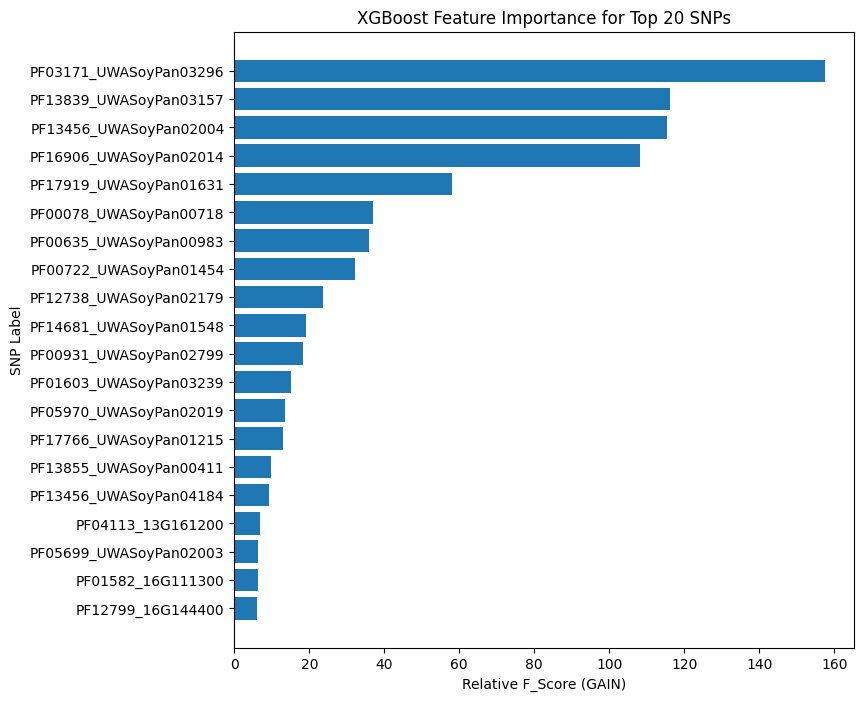

In [42]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, X_full, top_n=20)

In [43]:
explainer = shap.Explainer(best_xgbr_model)

In [45]:
shap_values = explainer(X, check_additivity=False)

<Axes: xlabel='SHAP value (impact on model output)'>

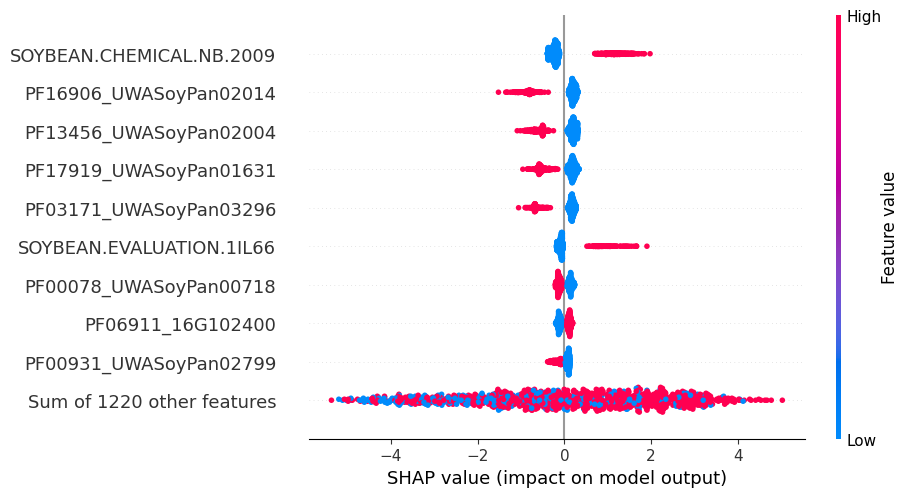

In [46]:
shap.plots.beeswarm(shap_values, show=False)

In [28]:
X_holdout = pd.read_pickle("x_holdout_pav.pkl")
X_holdout.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN015,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HNEX-04,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HNSM-12,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533429,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-480,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [29]:
y_holdout = pd.read_pickle("y_holdout_pav.pkl")
y_holdout.head()

,seed_oil
Data-storage-ID,
HN015,15.0
HNEX-04,20.3
HNSM-12,18.9
SRR1533429,22.4
USB-480,18.2


In [80]:
holdout_data = holdout_data.set_index('Data-storage-ID')

In [85]:
holdout_data.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,16.8
HN010,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,18.3
HN015,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,15.0
HN017B,0,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,15.5
HN023,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,15.6


In [86]:
X_holdout = holdout_data.iloc[:, 0:538334]
X_holdout.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN010,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
HN015,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
HN017B,0,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
HN023,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [87]:
y_holdout = holdout_data.iloc[:, 538334:]
y_holdout.head()

,seed_oil
Data-storage-ID,
HN009,16.8
HN010,18.3
HN015,15.0
HN017B,15.5
HN023,15.6


In [88]:
X_dupe.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,2,0,0,0,2,2,2,0,0,0,...,0,0,1,0,0,0,0,0,0,0
BR-24,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0


In [89]:
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [47]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, HN015 to USB-803
Columns: 1229 entries, PF00931_01G030900 to WILD.SOYBEAN.EVAL.1IL85
dtypes: int64(1229)
memory usage: 1.2+ MB


In [48]:
y_holdout.shape

(128, 1)

In [49]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.83
RMSE of Holdout: 1.36
Mean of Holdout: 16.91
This is 8.03% of the mean pheno data
0 15.0 14.48817
1 20.3 21.15866
2 18.9 19.929585
3 22.4 21.129982
4 18.2 20.41494
5 6.8 10.772297


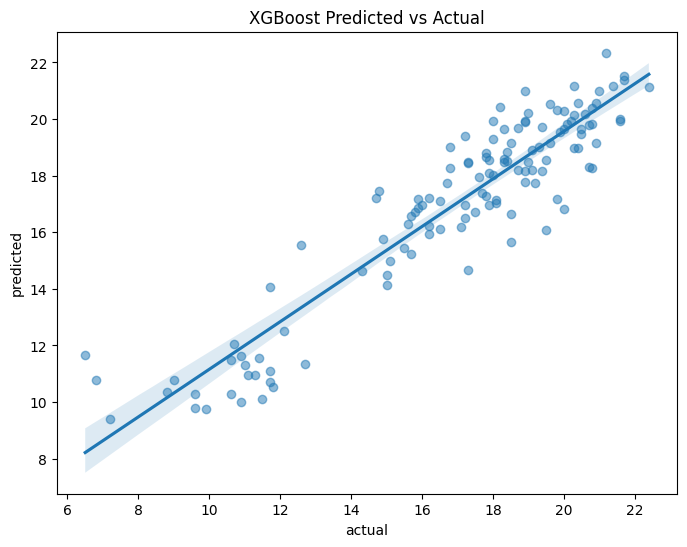

In [50]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [ ]:
y_pred_holdout = final_model.predict(X_holdout)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_holdout, y_pred_holdout))
r2 = r2_score(y_holdout, y_pred_holdout)

print(f"Holdout RMSE: {rmse:.2f}, R²: {r2:.2f}")

In [32]:
pickle.dump(best_xgbr_model, open("xgbr_pav_fullset_seedoil.pickle.dat", "wb"))

In [94]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 35), ('max_features', 'sqrt'), ('max_samples', 0.5129707634732739), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [95]:
best_rfr_model = eval_k_fold(best_rfreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7779676879315968
RMSE for dataset is:1.4606917235694705& mean of this fold is 17.45304347826087
this is 8.36926651439834% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6160133454423468
RMSE for dataset is:1.7166233624494485& mean of this fold is 17.46521739130435
this is 9.828811883579117% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.76190941710347
RMSE for dataset is:1.3810529758927523& mean of this fold is 17.64521739130435
this is 7.826783571243174% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7969229093686775
RMSE for dataset is:1.427139580795262& mean of this fold is 17.258260869565216
this is 8.269312832743243% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6640577073509819
RMSE for dataset 

R^2 Value of Holdout: 0.76
RMSE of Holdout: 1.57
Mean of Holdout: 16.91
This is 9.27% of the mean pheno data
0 16.8 19.14000000000001
1 18.3 17.104599999999962
2 15.0 16.02080000000002
3 15.5 16.379800000000042
4 15.6 16.680800000000012
5 18.1 16.54139999999999


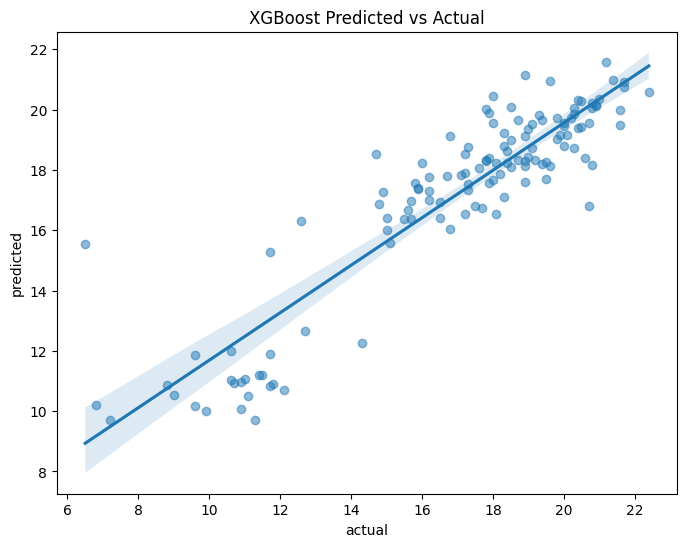

In [96]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [58]:
pickle.dump(best_rfr_model, open("lasso_allfeats_rfr_prt.pickle.dat", "wb"))

In [59]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [60]:
best_svr_model = eval_k_fold(best_svreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.3041025824475687
RMSE for dataset is:18.283068350207497& mean of this fold is 352.7580363636363
this is 5.182892086223266% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.05862413856210935
RMSE for dataset is:22.025010850335356& mean of this fold is 353.8857545454545
this is 6.223763055572889% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.32538067089091427
RMSE for dataset is:18.333457222470344& mean of this fold is 354.27561818181823
this is 5.174913621366235% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.10954064219020254
RMSE for dataset is:18.99306817748746& mean of this fold is 350.83194545454535
this is 5.413722559637389% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.11937159990261059
RMSE for

R^2 Value of Holdout: -0.68
RMSE of Holdout: 25.85
Mean of Holdout: 355.60
This is 7.27% of the mean pheno data
0 355.712 390.7872684612054
1 344.136 339.7552097655613
2 351.481 362.51181187066106
3 353.611 373.4750235381613
4 390.342 352.6819263452104
5 358.958 383.32305849869283


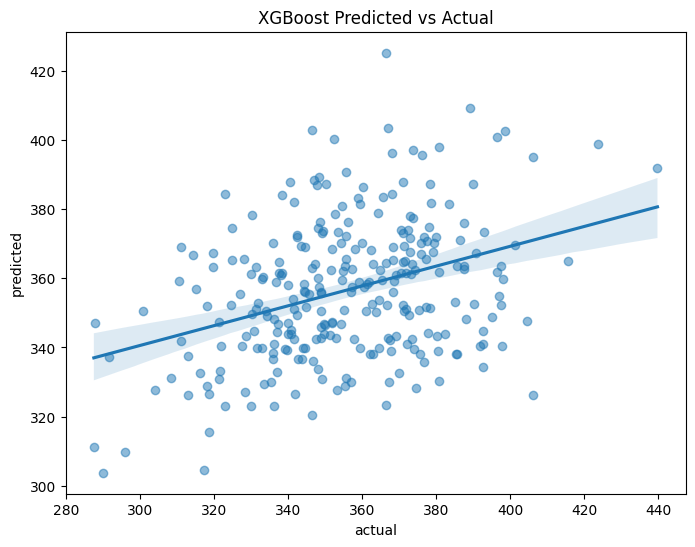

In [61]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

In [62]:
pickle.dump(best_svr_model, open("lasso_allfeats_svr_prt.pickle.dat", "wb"))

# After FS

In [21]:
fs_data = pd.read_pickle("../genotype/pfam_pav_newIDs_eval5_varthreshold_lasso_yield_training_data.pkl")

In [22]:
fs_data.head()

,PF00931_01G030900,PF00332_01G044800,PF10440_03G049800,PF13855_06G038900,PF01582_06G230600,PF02519_06G240800,PF05056_07G058300,PF02548_07G058400,PF05056_07G060200,PF00450_07G184300,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,1,1,1,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02_SOYBEAN.EVALUATION.MS2001_02,0,1,1,1,1,0,1,0,0,1,...,0,0,1,0,0,0,0,0,0,1.30
BR-01_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.33
BR-13_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.15
BR-14_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,2.87


In [23]:
snps_loc= fs_data.iloc[:, 0:156]

In [24]:
snps_loc.head()

,PF00931_01G030900,PF00332_01G044800,PF10440_03G049800,PF13855_06G038900,PF01582_06G230600,PF02519_06G240800,PF05056_07G058300,PF02548_07G058400,PF05056_07G060200,PF00450_07G184300,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,1,1,1,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02_SOYBEAN.EVALUATION.MS2001_02,0,1,1,1,1,0,1,0,0,1,...,0,0,0,1,0,0,0,0,0,0
BR-01_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
BR-13_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
BR-14_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0


In [25]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, AB-01_SOYBEAN.EVALUATION.4IL87 to USB-818_SOYBEAN.EVALUATION.IL2011_12_13
Columns: 156 entries, PF00931_01G030900 to SOYBEAN.EVALUATION.MS989
dtypes: int64(156)
memory usage: 984.9+ KB


In [26]:
snps_loc_dupe= fs_data.iloc[:, 0:156]
snps_loc_dupe.head()

,PF00931_01G030900,PF00332_01G044800,PF10440_03G049800,PF13855_06G038900,PF01582_06G230600,PF02519_06G240800,PF05056_07G058300,PF02548_07G058400,PF05056_07G060200,PF00450_07G184300,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,1,1,1,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02_SOYBEAN.EVALUATION.MS2001_02,0,1,1,1,1,0,1,0,0,1,...,0,0,0,1,0,0,0,0,0,0
BR-01_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
BR-13_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
BR-14_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0


In [27]:
y_all = fs_data["observation_value"].values

In [28]:
# Split training set into training and validation

In [29]:
X_train, X_test, y_train, y_test = train_test_split(snps_loc, y_all, test_size=0.1, random_state=42)

In [149]:
X_train = X_train.to_numpy()
#y_train = y_train.to_numpy()

In [150]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.3718270634215103), ('colsample_bytree', 1.0), ('gamma', 5.609923134071703e-09), ('learning_rate', 0.04508408749151527), ('max_delta_step', 9), ('max_depth', 16), ('min_child_weight', 9), ('n_estimators', 160), ('reg_alpha', 1.1013264802639234e-05), ('reg_lambda', 0.026247459441955348), ('subsample', 0.9141228426708968)])



=== Fold 1 ===
R²: 0.4557, RMSE: 0.6155, %RMSE: 29.63

=== Fold 2 ===
R²: 0.6361, RMSE: 0.5286, %RMSE: 22.64

=== Fold 3 ===
R²: 0.5942, RMSE: 0.6650, %RMSE: 29.44

=== Fold 4 ===
R²: 0.4781, RMSE: 0.5632, %RMSE: 24.76

=== Fold 5 ===
R²: 0.4272, RMSE: 0.6778, %RMSE: 29.45

=== Fold 6 ===
R²: 0.6157, RMSE: 0.4869, %RMSE: 21.23

=== Fold 7 ===
R²: 0.6227, RMSE: 0.5571, %RMSE: 23.61

=== Fold 8 ===
R²: 0.5756, RMSE: 0.5488, %RMSE: 25.02

=== Fold 9 ===
R²: 0.5529, RMSE: 0.6205, %RMSE: 27.01

=== Fold 10 ===
R²: 0.5559, RMSE: 0.5172, %RMSE: 23.76

CV Summary:
Mean %RMSE: 25.66 ± 2.90


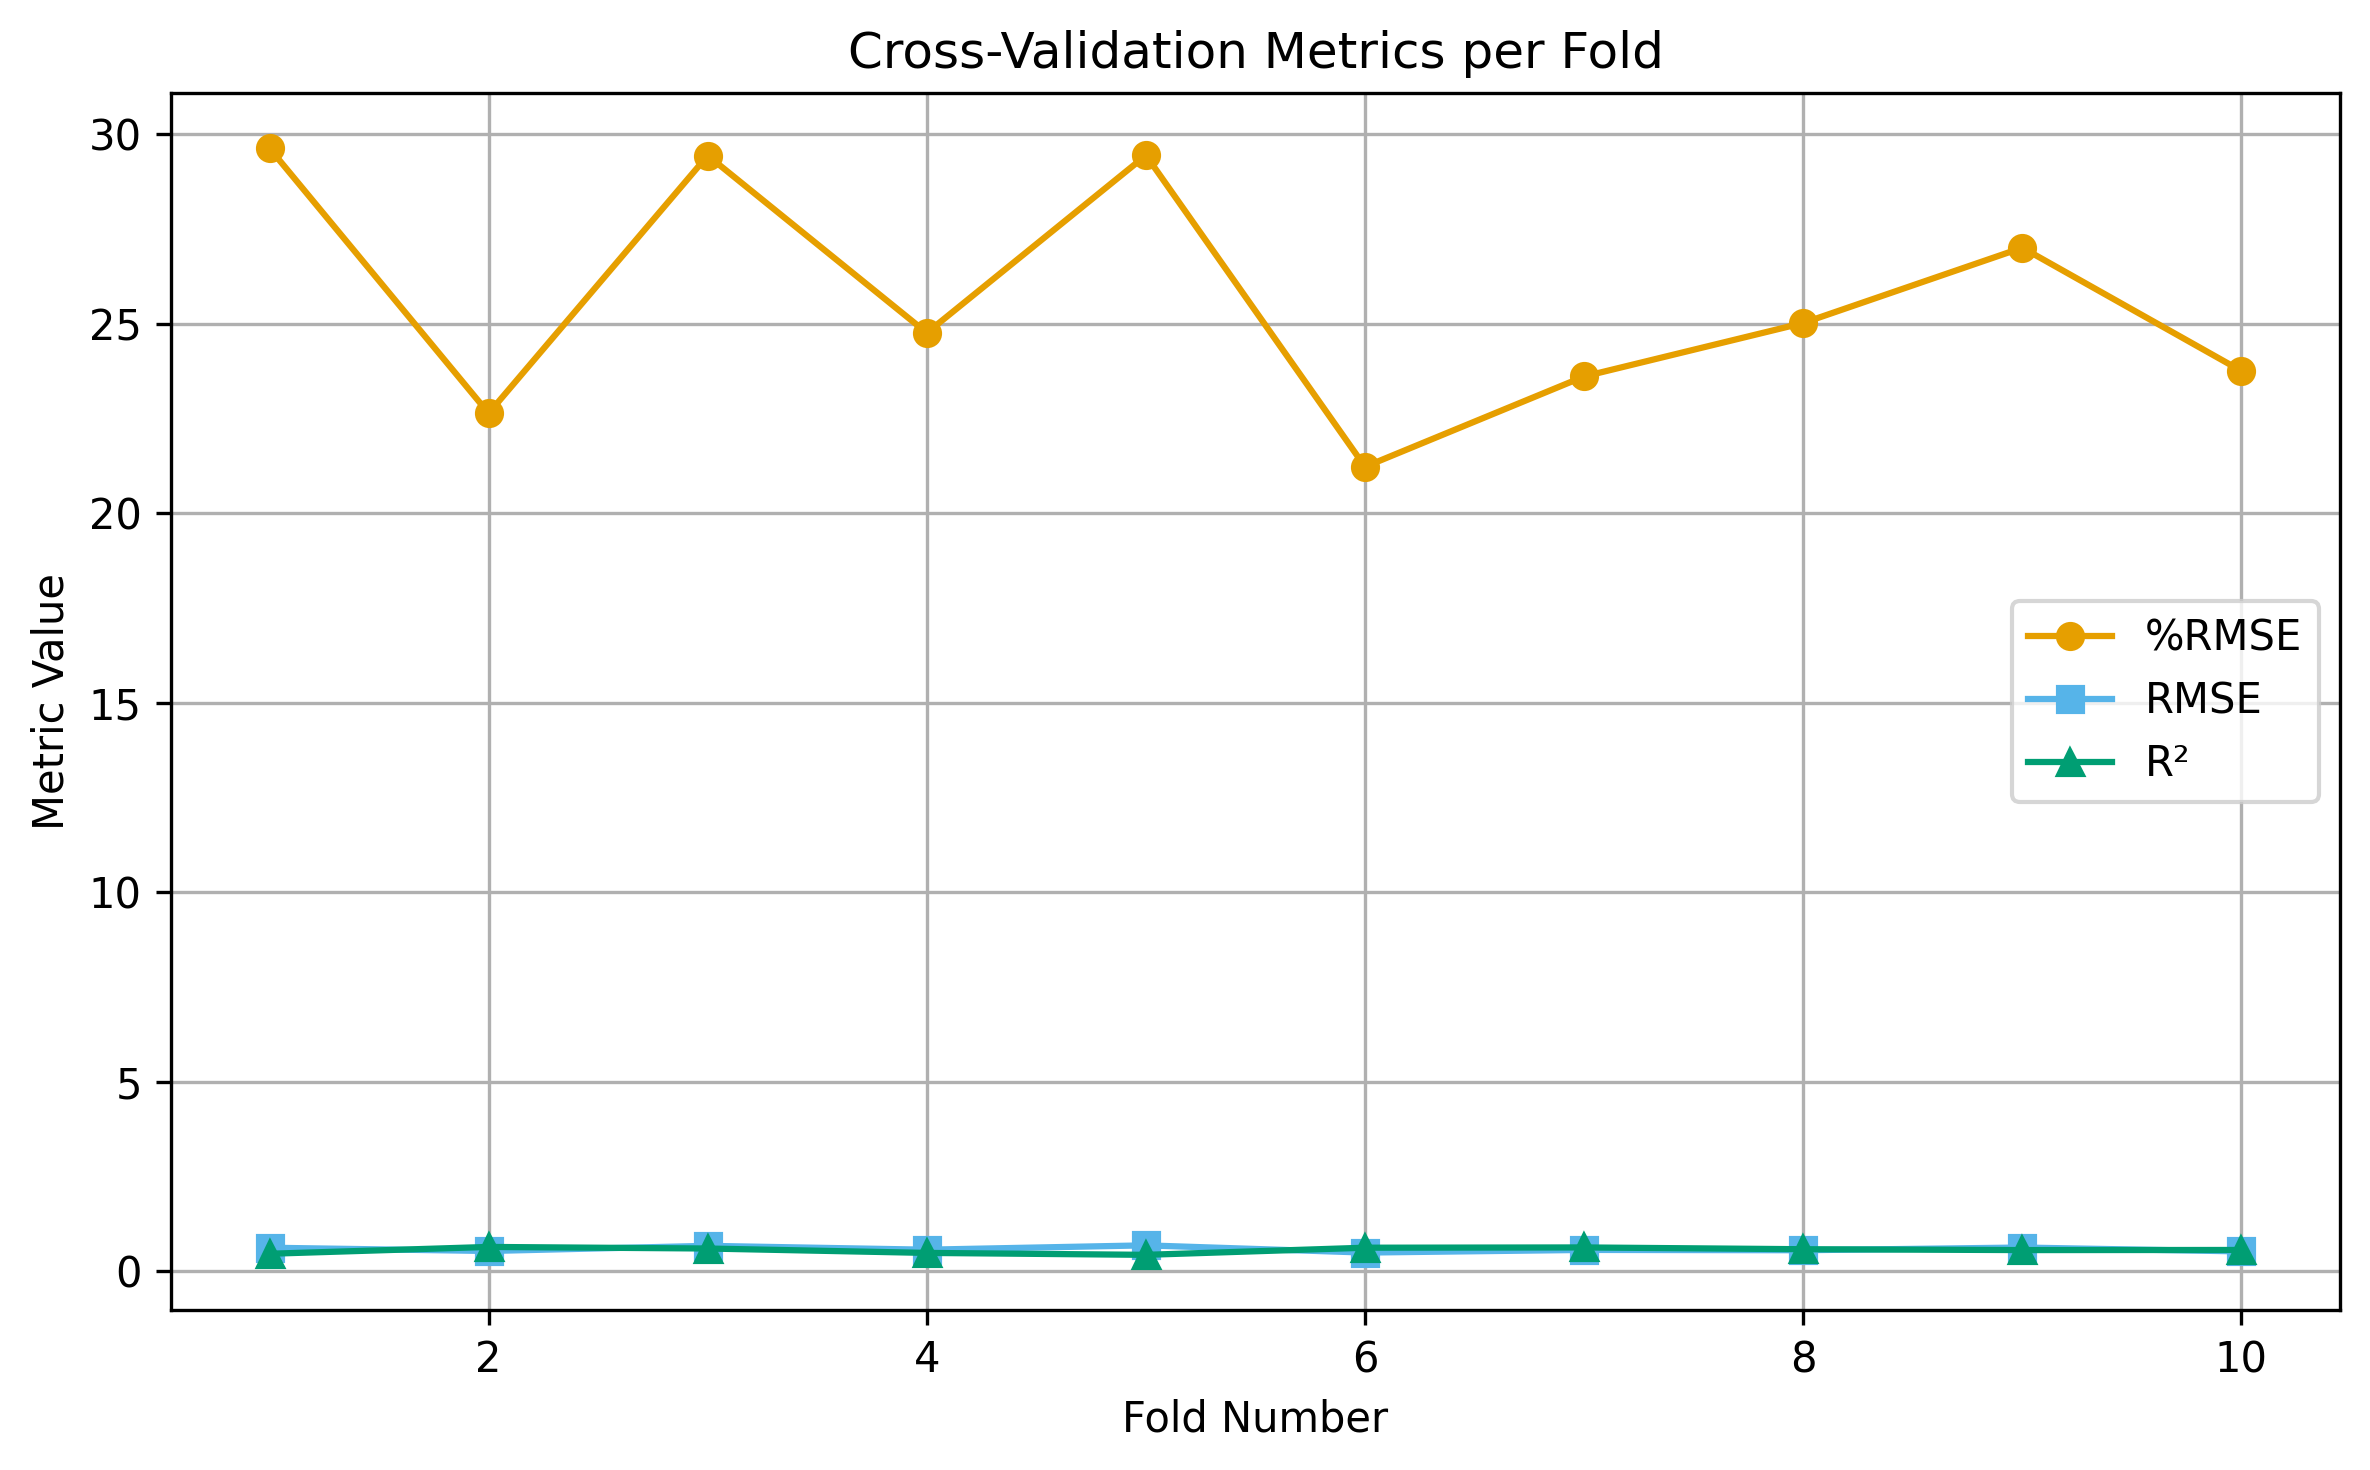

In [151]:
snps_loc = snps_loc.to_numpy()
#y_all = y_all.to_numpy()
best_xgbr_model,results = eval_k_fold(best_xgbreg, snps_loc, y_all, 10)

In [30]:
#pickle.dump(best_xgbr_model, open("pfam_pav_newIDs_eval5_lasso_yield.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("pickle_models/pfam_pav_newIDs_eval5_lasso_yield.pickle.dat", "rb"))

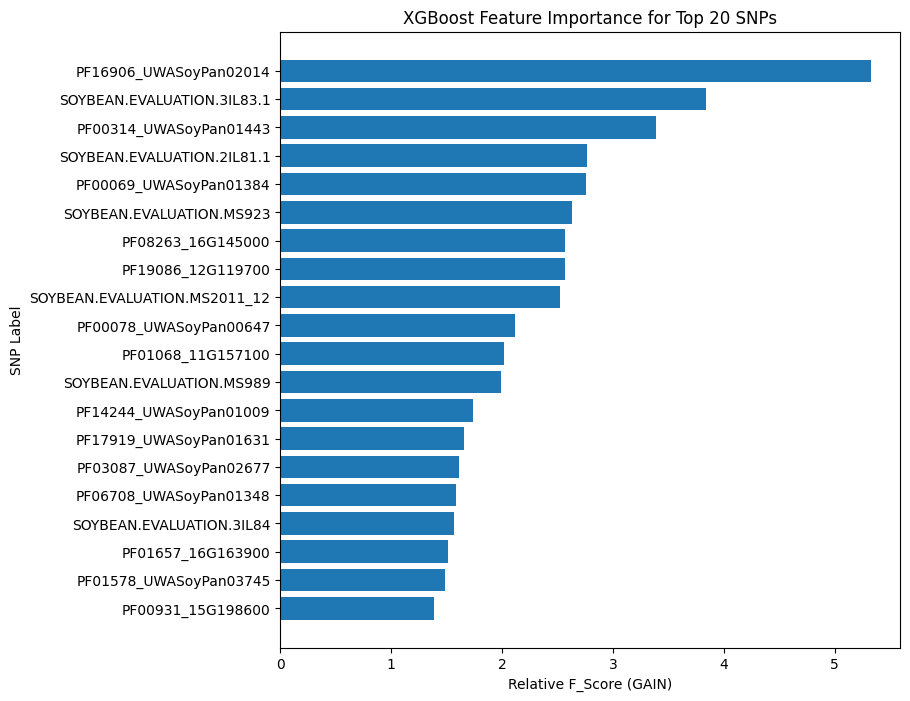

In [32]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, snps_loc_dupe, top_n=20, savepath="Pfam_lasso_yield_FI.png")

In [33]:
explainer = shap.Explainer(best_xgbr_model)

In [34]:
shap_values = explainer(snps_loc_dupe, check_additivity=False)

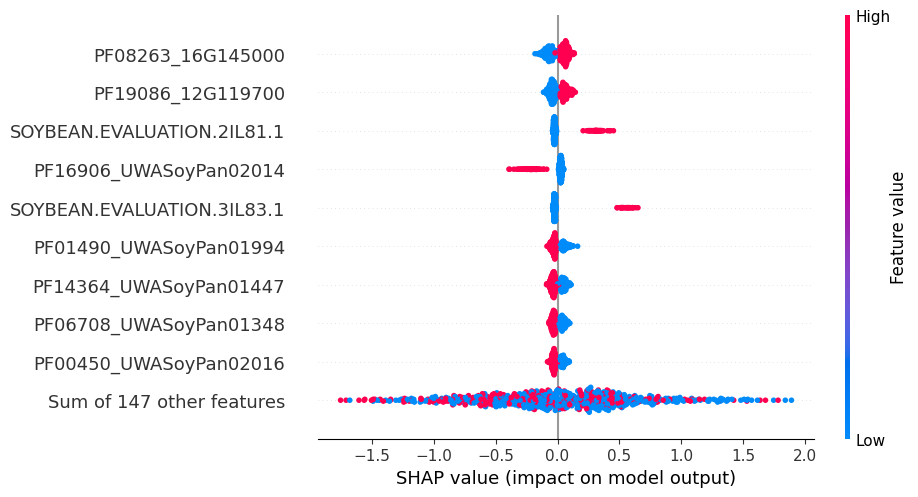

In [35]:
shap.plots.beeswarm(shap_values, show=False)
plt.savefig('pfam_lasso_yeild_shap.png', dpi=600, bbox_inches='tight')

In [30]:
holdout_data = pd.read_pickle("pfam_pav_newIDs_eval5_varthreshold_holdout_data_pav.pkl")
holdout_data.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN009_SOYBEAN.EVALUATION.5IL90,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,16.8
HN010_SOYBEAN.EVALUATION.4IL87,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,18.3
HN015_SOYBEAN.EVALUATION.3IL83.2,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15.0
HN017B_SOYBEAN.EVALUATION.3IL83.2,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.5
HN023_SOYBEAN.EVALUATION.2IL81.2,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15.6


In [157]:
holdout_data['Data-storage-ID'] = holdout_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
holdout_data = holdout_data.reset_index(drop=True).set_index('Data-storage-ID')
holdout_data.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,3.60
HN012,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.86
HN018,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.87
HN037,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.88
HN060,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.02


In [158]:
X_holdout = holdout_data.iloc[:, 0:53752]
X_holdout.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
HN012,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN018,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN037,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN060,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [159]:
y_holdout = holdout_data.iloc[:, 53752:]
y_holdout.head()

,observation_value
Data-storage-ID,
ESS,3.60
HN012,1.86
HN018,1.87
HN037,1.88
HN060,2.02


In [160]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [161]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, ESS to USB-807
Columns: 156 entries, PF00931_01G030900 to SOYBEAN.EVALUATION.MS989
dtypes: int64(156)
memory usage: 110.4+ KB


In [162]:
X_holdout.head()

,PF00931_01G030900,PF00332_01G044800,PF10440_03G049800,PF13855_06G038900,PF01582_06G230600,PF02519_06G240800,PF05056_07G058300,PF02548_07G058400,PF05056_07G060200,PF00450_07G184300,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
HN012,0,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN018,0,0,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN037,0,1,0,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
HN060,0,1,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [163]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.54
RMSE of Holdout: 0.55
Mean of Holdout: 2.19
This is 25.22% of the mean pheno data
0 3.6 2.7034812
1 1.86 1.6904745
2 1.87 1.7811551
3 1.88 1.6615846
4 2.02 1.7329742


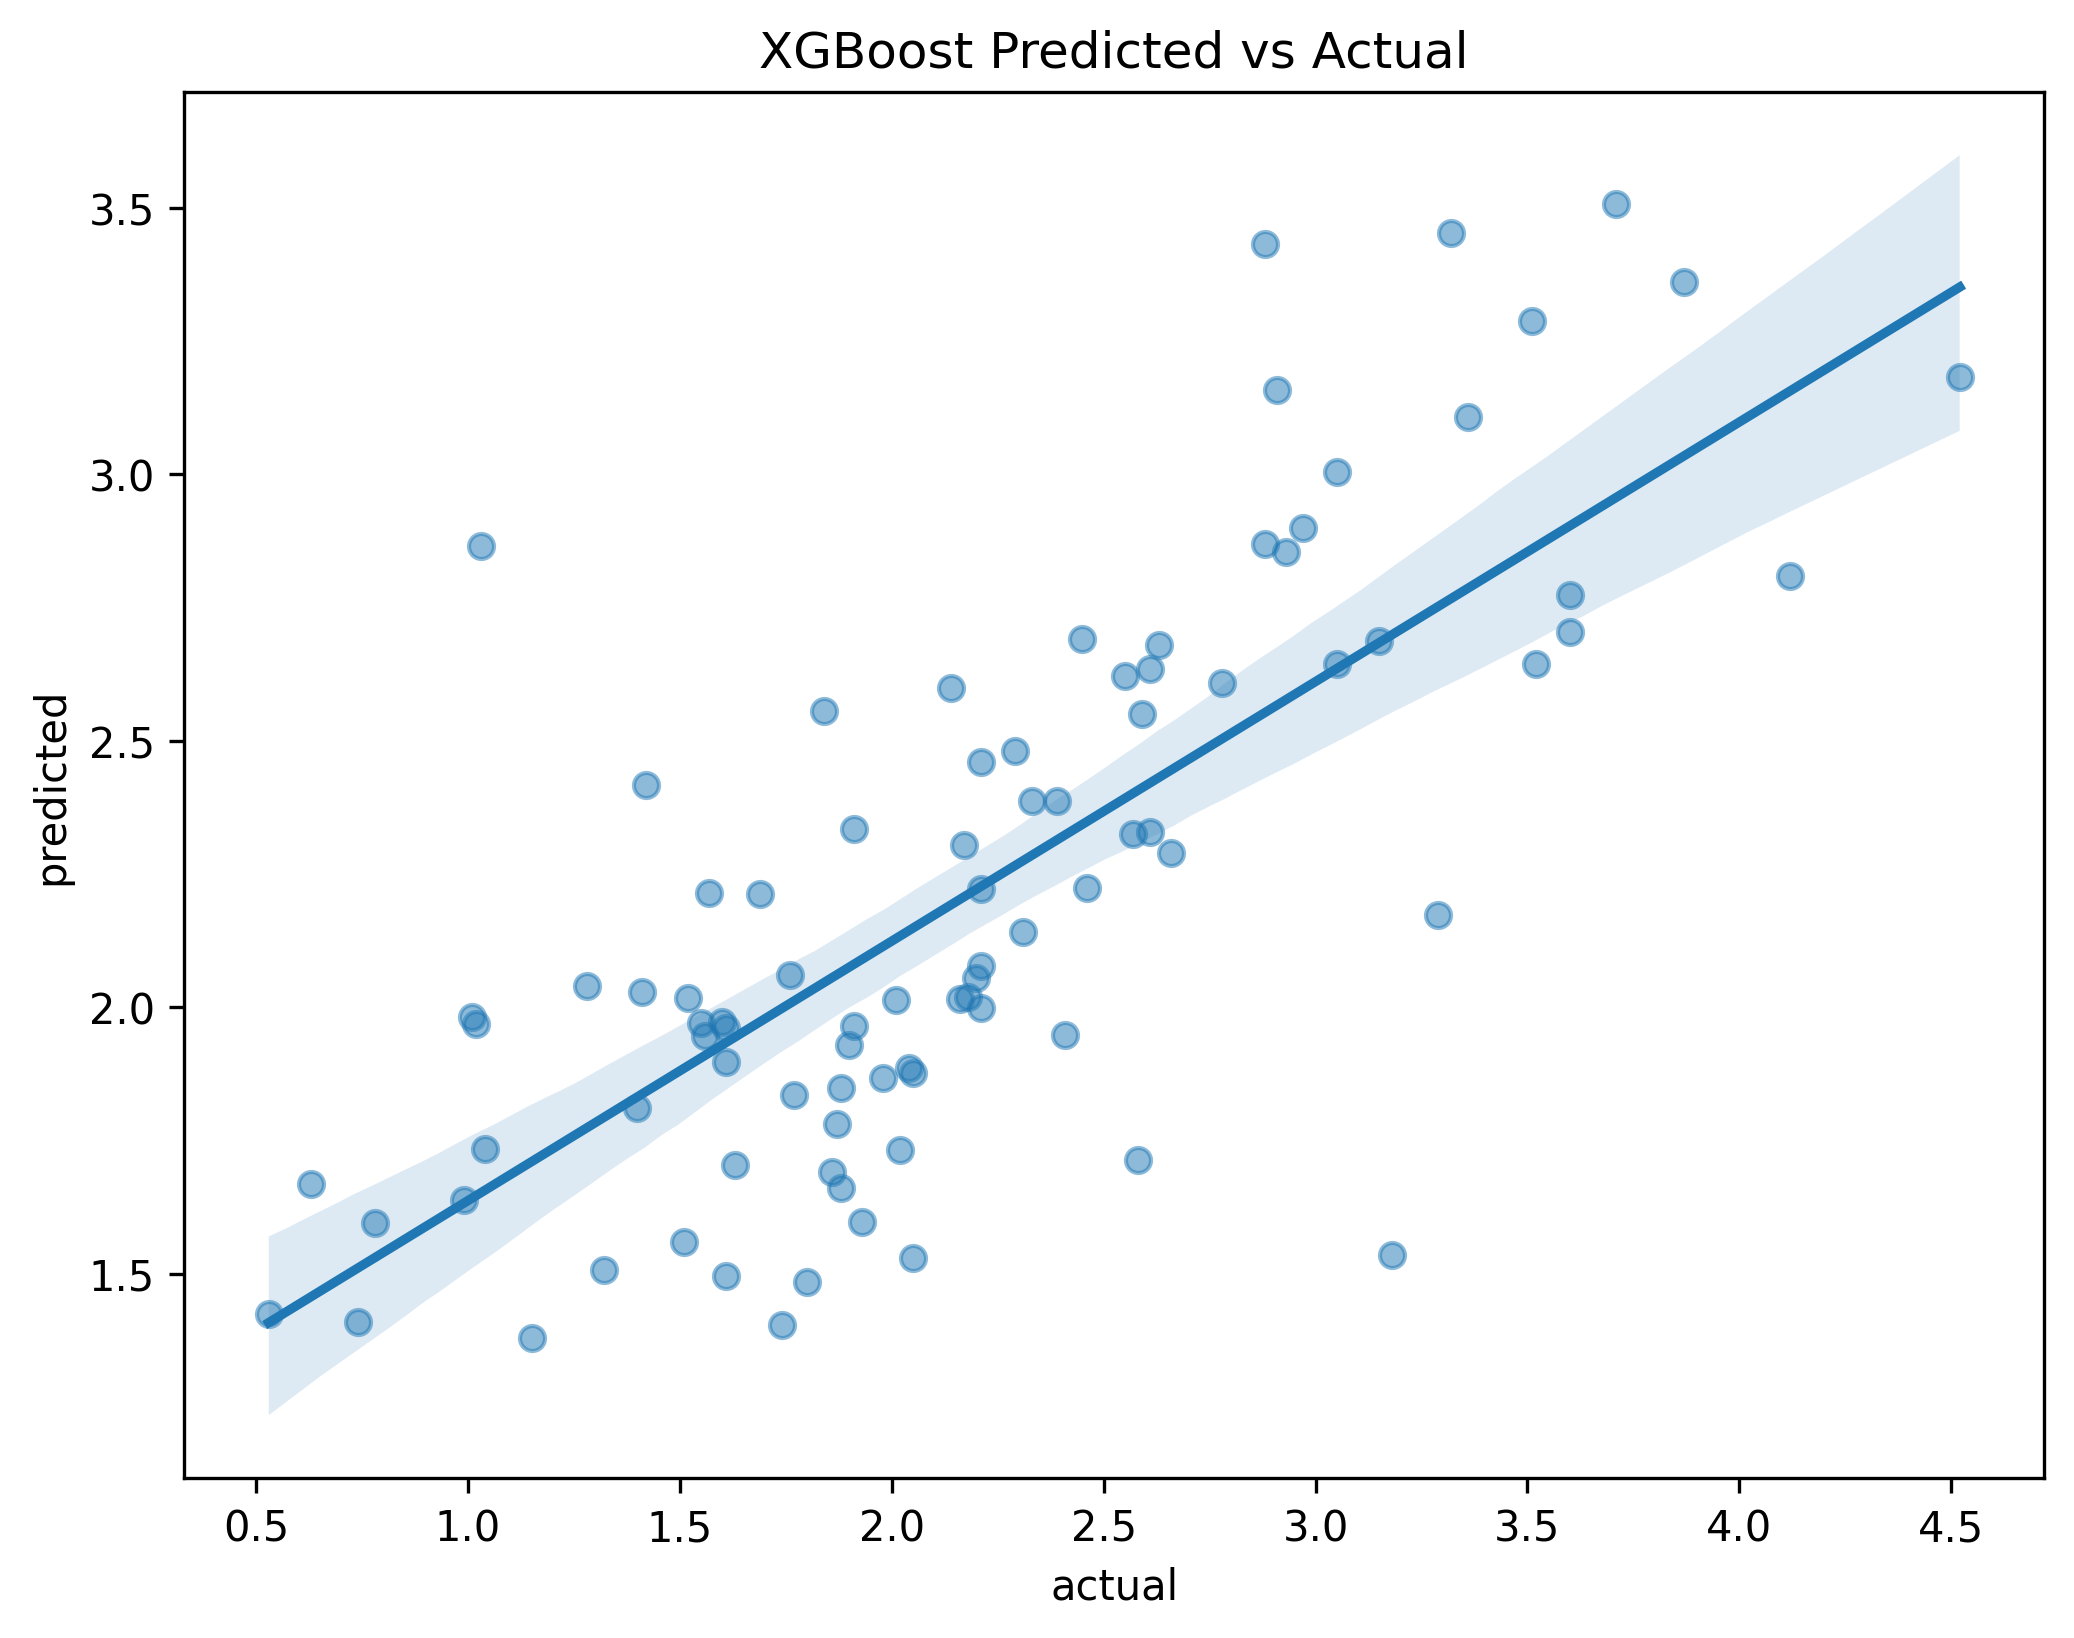

In [164]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

0 355.712 355.62405
1 344.136 357.9013
2 351.481 360.10144
3 353.611 363.17737
4 390.342 359.04974
5 358.958 358.19962


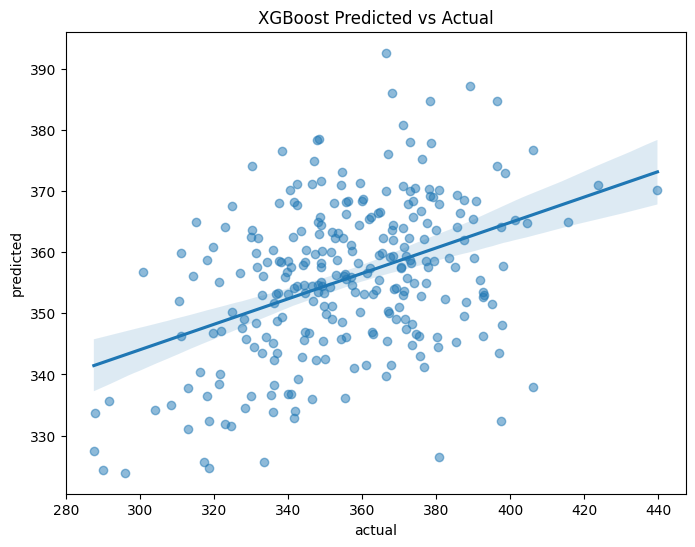

In [36]:
 # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])
# Create a DataFrame for plotting
thisplot = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

    # Generate regression plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
plt.title('XGBoost Predicted vs Actual')
plt.savefig('prt_xgbr_lasso_onlyloc_pav.png', dpi=300, bbox_inches='tight')

# Variance threshold

In [36]:
fs_data = pd.read_pickle("../genotype/pfam_pav_newIDs_eval5_varthreshold_yield_training_data.pkl")

In [37]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, HNSM-03_SOYBEAN.EVALUATION.2KY81 to USB-752_SOYBEAN.EVALUATION.MS989
Columns: 1228 entries, PF00931_01G030900 to observation_value
dtypes: float64(1), int64(1227)
memory usage: 7.5+ MB


In [38]:
fs_data['Data-storage-ID'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Data-storage-ID')
fs_data.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HNSM-03,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.50
USB-127,0,0,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,2.47
USB-475,0,0,1,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.65
SRR1533290,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.12
SRR1533220,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,1.06


In [39]:
only_snps = fs_data.iloc[:, 0:1227]
only_snps.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HNSM-03,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-127,0,0,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
USB-475,0,0,1,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533290,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533220,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0


In [40]:
only_snps_dupe = fs_data.iloc[:, 0:1227]
only_snps.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HNSM-03,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-127,0,0,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
USB-475,0,0,1,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533290,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533220,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0


In [41]:
y_all = fs_data["observation_value"]
y_all.head()

Data-storage-ID
HNSM-03       1.50
USB-127       2.47
USB-475       2.65
SRR1533290    2.12
SRR1533220    1.06
Name: observation_value, dtype: float64

### Run models

In [42]:
X_train, X_test, y_train, y_test = train_test_split(only_snps, y_all, test_size=0.1, random_state=42)

In [173]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [174]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5239624105081416), ('colsample_bytree', 0.8261377498300351), ('gamma', 0.4488261560654352), ('learning_rate', 0.04260235574879461), ('max_delta_step', 6), ('max_depth', 34), ('min_child_weight', 3), ('n_estimators', 184), ('reg_alpha', 0.00271616009282334), ('reg_lambda', 0.059799187519270804), ('subsample', 0.6599385823907706)])



=== Fold 1 ===
R²: 0.5103, RMSE: 0.5607, %RMSE: 26.15

=== Fold 2 ===
R²: 0.6016, RMSE: 0.6636, %RMSE: 28.46

=== Fold 3 ===
R²: 0.4981, RMSE: 0.7023, %RMSE: 29.58

=== Fold 4 ===
R²: 0.4756, RMSE: 0.6023, %RMSE: 26.17

=== Fold 5 ===
R²: 0.4898, RMSE: 0.6543, %RMSE: 28.27

=== Fold 6 ===
R²: 0.5687, RMSE: 0.5353, %RMSE: 24.41

=== Fold 7 ===
R²: 0.4962, RMSE: 0.5698, %RMSE: 25.77

=== Fold 8 ===
R²: 0.5099, RMSE: 0.5508, %RMSE: 25.18

=== Fold 9 ===
R²: 0.5051, RMSE: 0.5092, %RMSE: 23.23

=== Fold 10 ===
R²: 0.2537, RMSE: 0.8056, %RMSE: 34.80

CV Summary:
Mean %RMSE: 27.20 ± 3.13


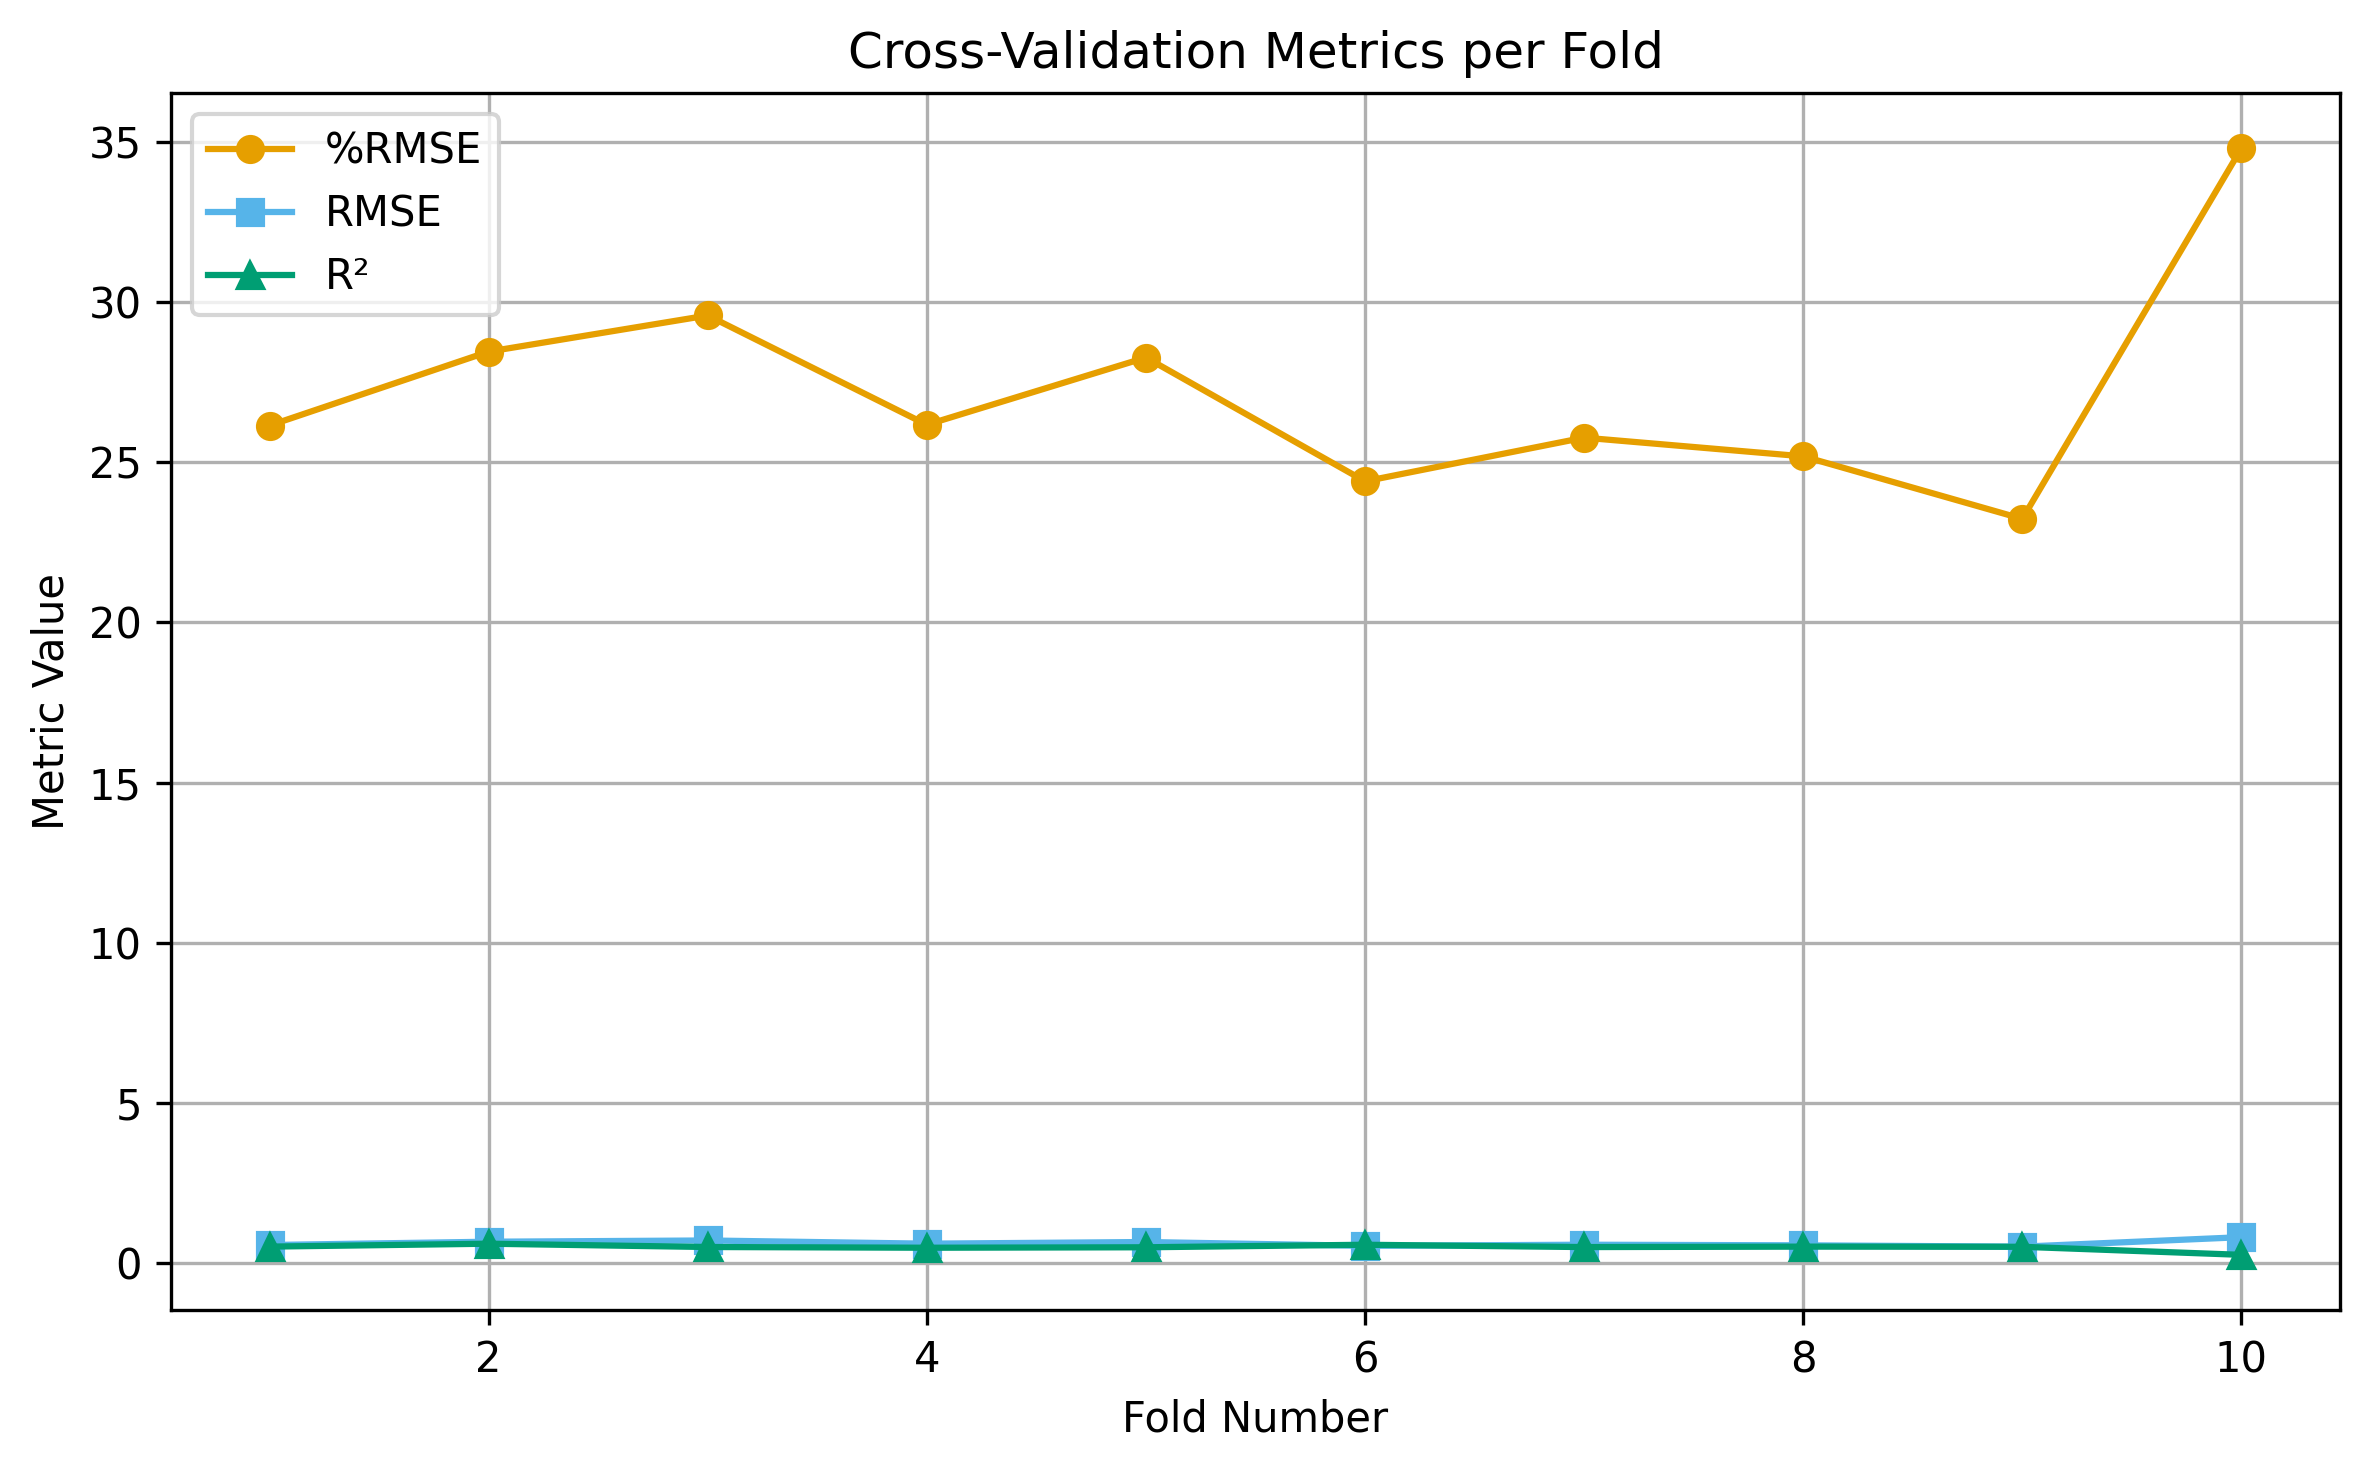

In [175]:
only_snps = only_snps.to_numpy()
y_all = y_all.to_numpy() 
best_xgbr_model, results = eval_k_fold(best_xgbreg, only_snps, y_all, 10)

In [43]:
#pickle.dump(best_xgbr_model, open("pfam_pav_newIDs_eval5_varthreshold_yield.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("pickle_models/pfam_pav_newIDs_eval5_varthreshold_yield.pickle.dat", "rb"))

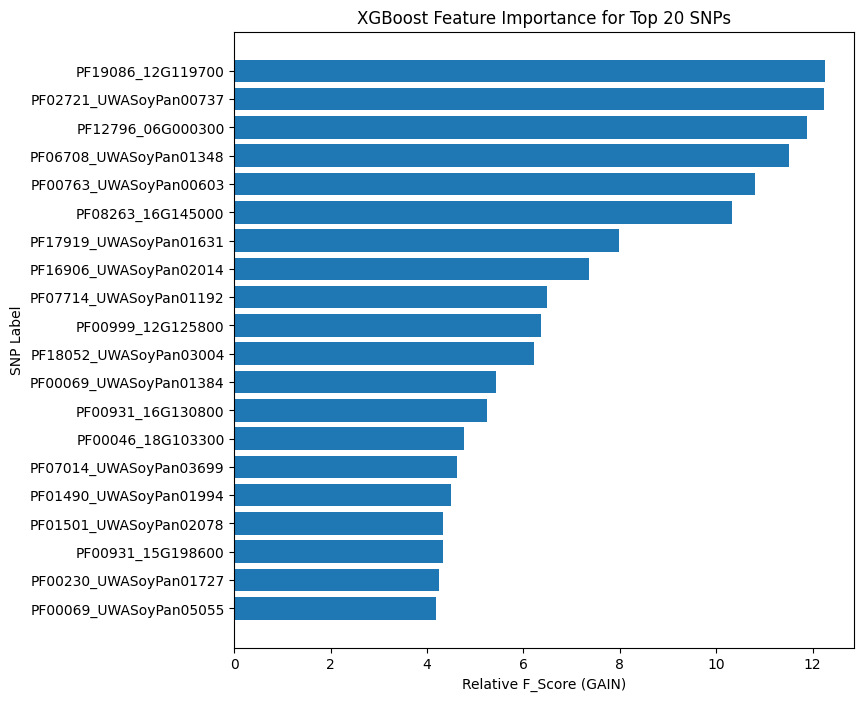

In [44]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, only_snps_dupe , top_n=20, savepath="pfam_vt_yield_FI.png")

In [45]:
explainer = shap.Explainer(best_xgbr_model)

In [46]:
shap_values = explainer(only_snps_dupe)

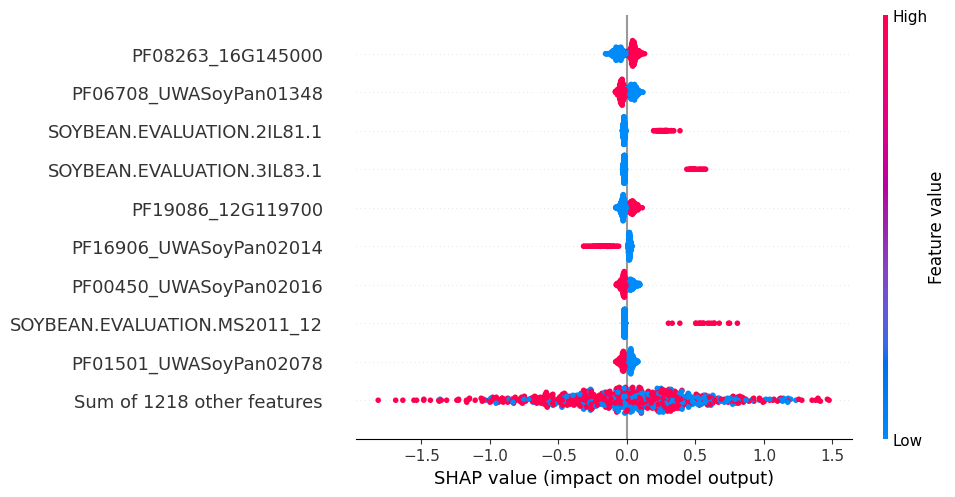

In [49]:
shap.plots.beeswarm(shap_values, show=False)
plt.savefig('Pfam_vt_yield_shap.png', dpi=600, bbox_inches='tight')

In [54]:
holdout_data = pd.read_pickle("pfam_pav_newIDs_eval5_varthreshold_holdout_data_pav.pkl")
holdout_data.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN009_SOYBEAN.EVALUATION.5IL90,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,16.8
HN010_SOYBEAN.EVALUATION.4IL87,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,18.3
HN015_SOYBEAN.EVALUATION.3IL83.2,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15.0
HN017B_SOYBEAN.EVALUATION.3IL83.2,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.5
HN023_SOYBEAN.EVALUATION.2IL81.2,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,15.6


In [183]:
holdout_data['Data-storage-ID'] = holdout_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
holdout_data = holdout_data.reset_index(drop=True).set_index('Data-storage-ID')
holdout_data.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,3.60
HN012,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.86
HN018,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.87
HN037,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.88
HN060,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.02


In [184]:
X_holdout = holdout_data.iloc[:, 0:53752]
X_holdout.head()

,PF02776_01G000400,PF04434_01G000700,PF10551_01G000700,PF03101_01G000800,PF04434_01G000800,PF10551_01G000800,PF09229_01G001000,PF03040_01G001100,PF13243_01G001300,PF13249_01G001300,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
HN012,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN018,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN037,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN060,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [185]:
y_holdout = holdout_data.iloc[:, 53752:]
y_holdout.head()

,observation_value
Data-storage-ID,
ESS,3.60
HN012,1.86
HN018,1.87
HN037,1.88
HN060,2.02


In [186]:
# Ensure both trainjg and holdout datasets have the same columns
only_snps_dupe, X_holdout = only_snps_dupe.align(X_holdout, join='inner', axis=1)

In [187]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, ESS to USB-807
Columns: 1227 entries, PF00931_01G030900 to SOYBEAN.EVALUATION.MS989
dtypes: int64(1227)
memory usage: 863.4+ KB


In [188]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.54
RMSE of Holdout: 0.56
Mean of Holdout: 2.19
This is 25.42% of the mean pheno data
0 3.6 2.771825
1 1.86 1.6337093
2 1.87 1.9658042
3 1.88 1.6905023
4 2.02 1.9914101


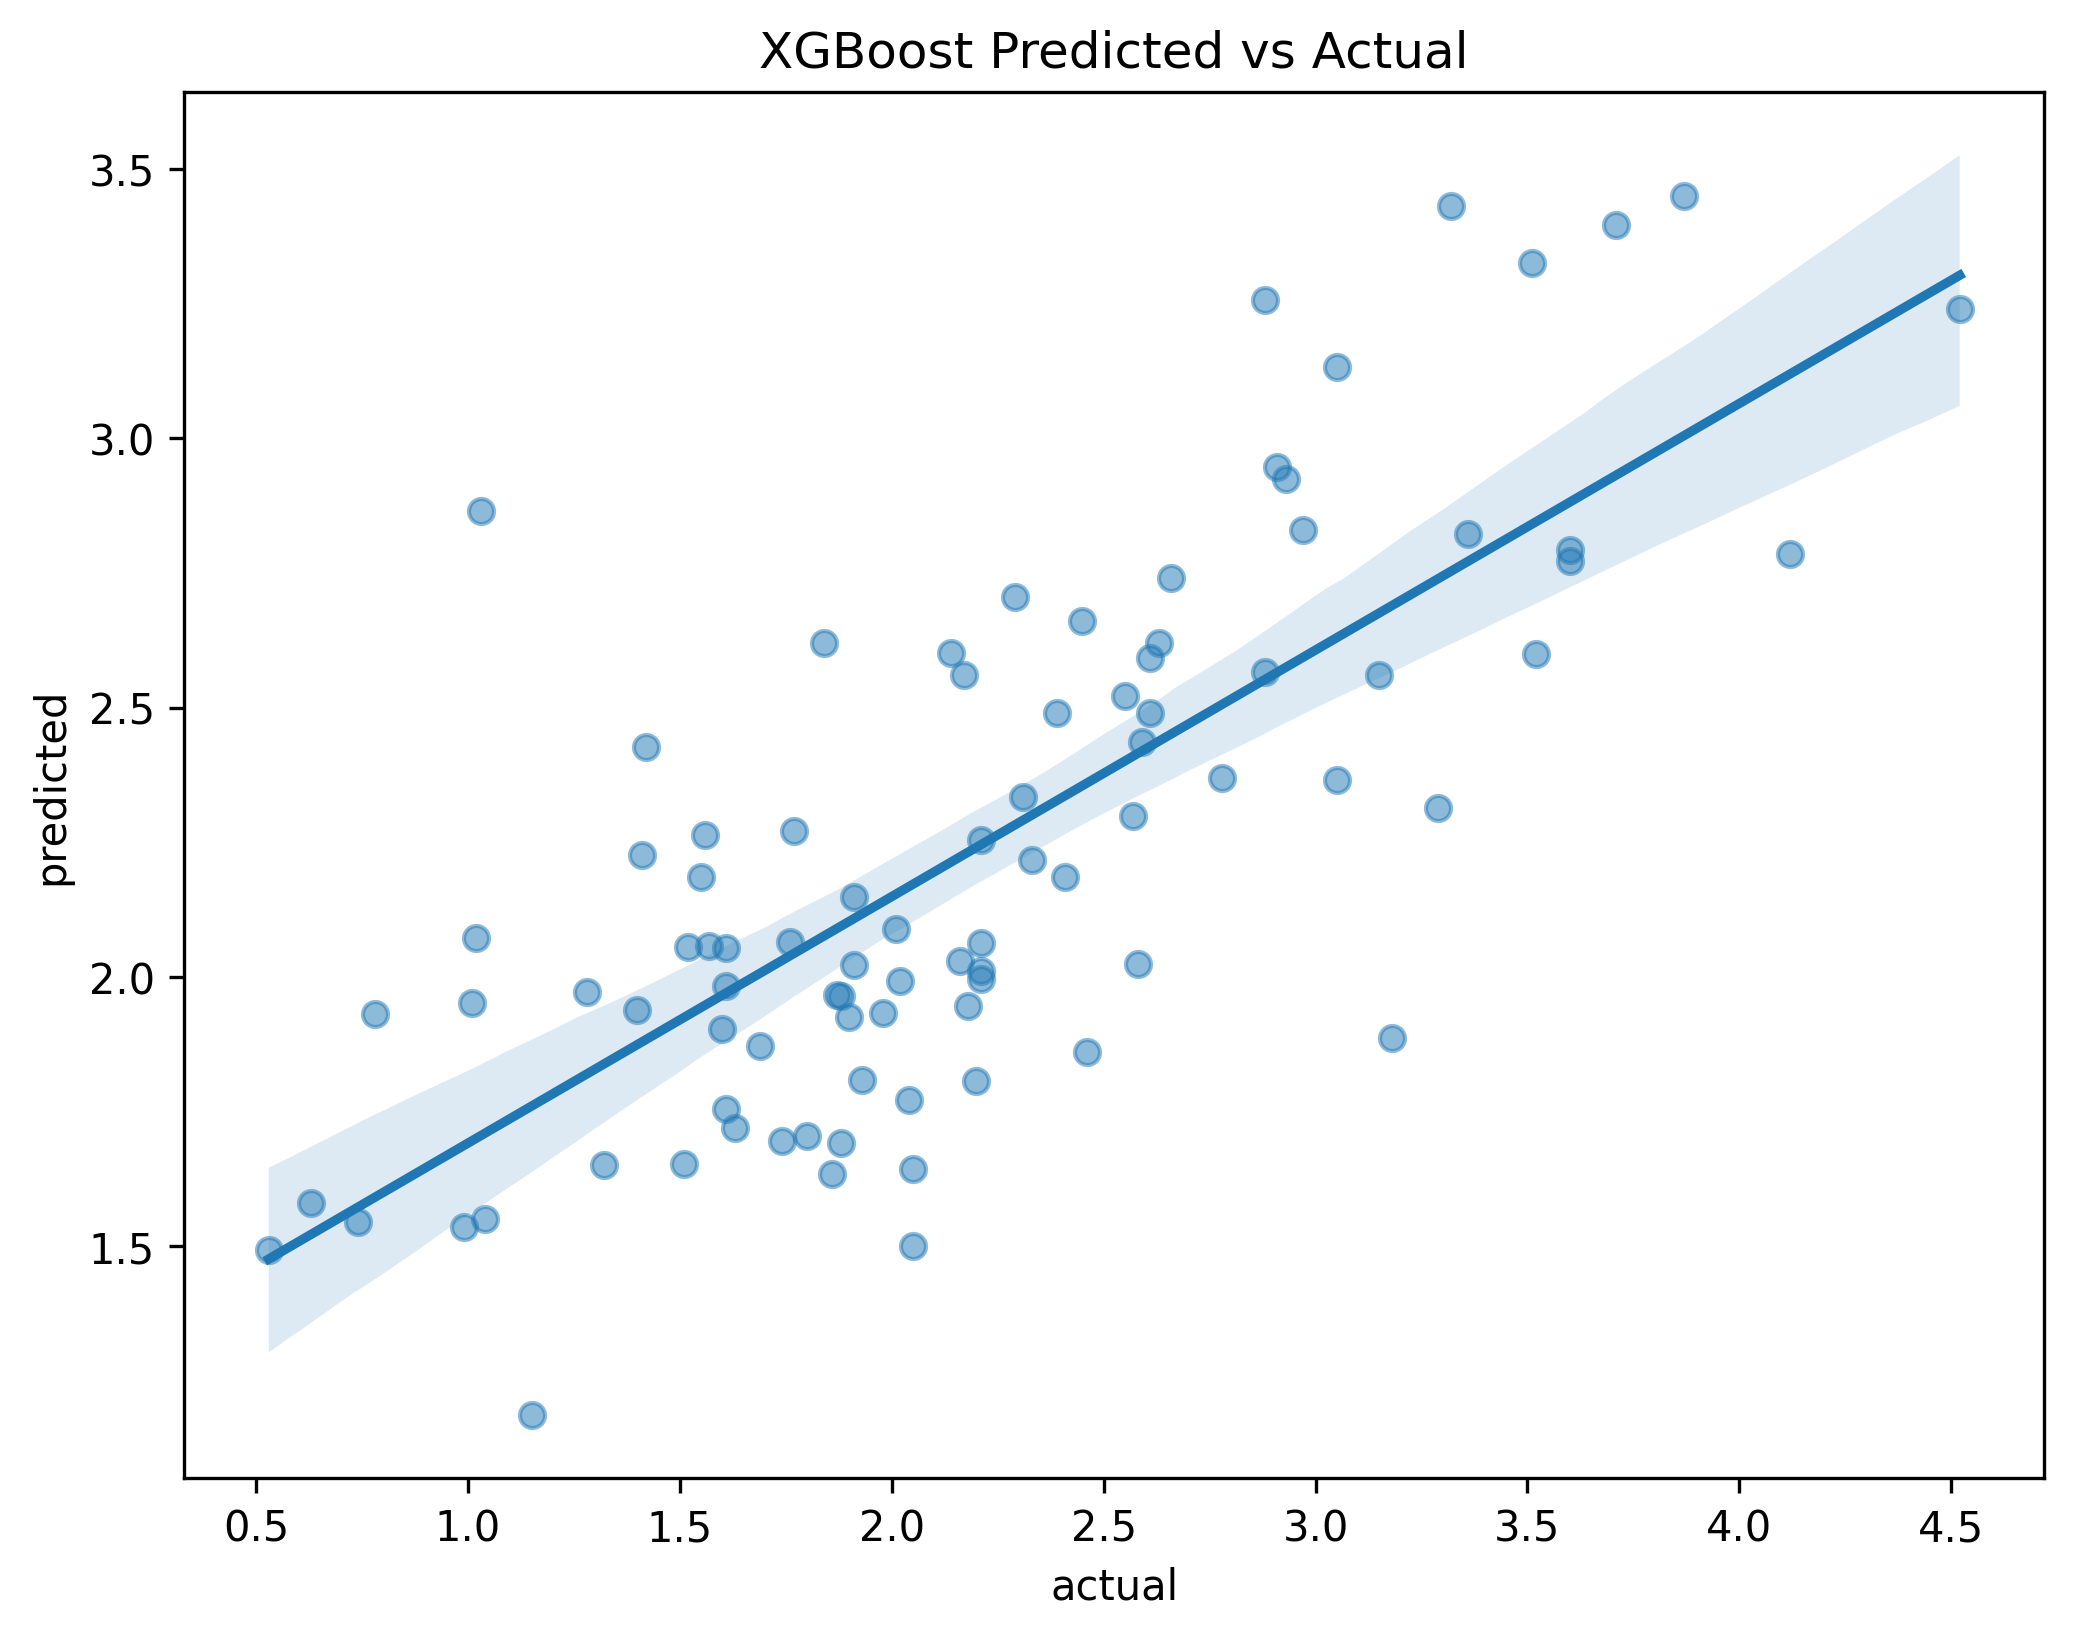

In [189]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)